## Loan Default Prediction

**Task:** Build a complete baseline-to-final classical ML pipeline on a fixed-spec loan-application dataset, predicting whether an applicant defaults, using income, loan amount, employment type, and credit score.

**Key challenge:** `credit_score` has genuine missing values (90 out of 1200 rows) — how these are handled, and *when* (before or after the train/test split), is the first and most important decision in this pipeline, since doing it at the wrong point causes data leakage.

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(seed=55)
n = 1200

employment_type = rng.choice(["Salaried", "Self-Employed", "Contract"], size=n, p=[0.5, 0.28, 0.22])
credit_score = rng.normal(650, 60, size=n).clip(300, 850).round(0)
applicant_income = rng.normal(55000, 20000, size=n).clip(15000, None).round(0)
loan_amount = rng.normal(15000, 7000, size=n).clip(1000, None).round(0)

loan_to_income = loan_amount / applicant_income
emp_risk = pd.Series(employment_type).map({"Salaried": 0, "Self-Employed": 0.3, "Contract": 0.6}).values
z = (-0.035 * (credit_score - 650) + 4.5 * loan_to_income + emp_risk * 1.2 - 1.0 + rng.normal(0, 1.1, size=n))
prob_default = 1 / (1 + np.exp(-z))
default = (rng.uniform(size=n) < prob_default).astype(int)

missing_idx = rng.choice(n, 90, replace=False)
credit_score[missing_idx] = np.nan

loans = pd.DataFrame({
    "applicant_id": np.arange(1, n + 1),
    "employment_type": employment_type,
    "credit_score": credit_score,
    "applicant_income": applicant_income,
    "loan_amount": loan_amount,
    "default": default,
})

# Self-check
assert loans.shape == (1200, 6)
assert loans["credit_score"].isna().sum() == 90
print("Setup confirmed — dataset matches spec.")

Setup confirmed — dataset matches spec.


## Quick diagnosis before building anything

Checking the shape, missing values, and class balance before touching the pipeline -- same habit as every dataset this program has used.

In [2]:
print(f"Dataset shape: {loans.shape}")
print(f"Missing credit_score values: {loans['credit_score'].isna().sum()}")
print(f"\nClass balance (default):")
print(loans['default'].value_counts())
print(f"\nDefault rate: {loans['default'].mean():.1%}")

Dataset shape: (1200, 6)
Missing credit_score values: 90

Class balance (default):
default
1    720
0    480
Name: count, dtype: int64

Default rate: 60.0%


In [3]:
from IPython.display import Markdown, display

default_rate = loans['default'].mean()
missing_count = loans['credit_score'].isna().sum()

display(Markdown(f"""
### Diagnosis findings

The dataset has **{loans.shape[0]} rows** and **{loans.shape[1]} columns**, with **{missing_count} missing values** in `credit_score` (bureau data not always available for every applicant).

The target class is **not balanced 50/50** -- the default rate is **{default_rate:.1%}**, meaning class 1 (default) is actually the *majority* class here, which is somewhat counter-intuitive for a "loan default" dataset and will shape what the baseline looks like.
"""))


### Diagnosis findings

The dataset has **1200 rows** and **6 columns**, with **90 missing values** in `credit_score` (bureau data not always available for every applicant).

The target class is **not balanced 50/50** -- the default rate is **60.0%**, meaning class 1 (default) is actually the *majority* class here, which is somewhat counter-intuitive for a "loan default" dataset and will shape what the baseline looks like.


## Step 1: Build features

In [4]:
X = loans[["credit_score", "applicant_income", "loan_amount", "employment_type"]]
X = pd.get_dummies(X, columns=["employment_type"], drop_first=True)
y = loans["default"]

print(f"X shape: {X.shape}")
print(f"Columns: {list(X.columns)}")
print(f"Missing values still in X: {X['credit_score'].isna().sum()}")

X.head()

X shape: (1200, 5)
Columns: ['credit_score', 'applicant_income', 'loan_amount', 'employment_type_Salaried', 'employment_type_Self-Employed']
Missing values still in X: 90


,credit_score,applicant_income,loan_amount,employment_type_Salaried,employment_type_Self-Employed
0,731.0,78406.0,8301.0,False,False
1,717.0,59130.0,6699.0,False,False
2,713.0,71809.0,4456.0,True,False
3,625.0,41497.0,20290.0,True,False
4,652.0,64193.0,10890.0,True,False


Using only the four predictive columns (`applicant_id` excluded -- it's just a row identifier, not a feature). `employment_type` is one-hot encoded with `drop_first=True` to avoid the dummy variable trap. `credit_score`'s missing values are deliberately left untouched here -- they get handled only after the train/test split, in Step 3.

## Step 2: Split before touching missing values

The split happens here, deliberately *before* `credit_score`'s NaNs are handled. `X` at this point still contains the 90 missing values -- splitting first and imputing after (using only the training set) is what prevents data leakage: if the fill value were computed from the full dataset, information from the test set would indirectly influence the training data, making the evaluation overly optimistic and not representative of real-world performance.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Missing values in X_train: {X_train['credit_score'].isna().sum()}")
print(f"Missing values in X_test: {X_test['credit_score'].isna().sum()}")
print(f"\nTrain default rate: {y_train.mean():.1%}")
print(f"Test default rate: {y_test.mean():.1%}")

X_train shape: (960, 5)
X_test shape: (240, 5)
Missing values in X_train: 71
Missing values in X_test: 19

Train default rate: 60.0%
Test default rate: 60.0%


## Step 3: Impute `credit_score` — training set only

The fill value (median) is computed from `X_train["credit_score"]` alone, then applied to *both* `X_train` and `X_test`. The test set's own missing values are filled using a number the test set had no part in producing -- this is what keeps the split honest as a stand-in for genuinely unseen future data.

In [6]:
credit_score_fill_value = X_train["credit_score"].median()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["credit_score"] = X_train["credit_score"].fillna(credit_score_fill_value)
X_test["credit_score"] = X_test["credit_score"].fillna(credit_score_fill_value)

print(f"Imputation value (median of X_train['credit_score']): {credit_score_fill_value}")
print(f"Missing values in X_train after imputation: {X_train['credit_score'].isna().sum()}")
print(f"Missing values in X_test after imputation: {X_test['credit_score'].isna().sum()}")

Imputation value (median of X_train['credit_score']): 649.0
Missing values in X_train after imputation: 0
Missing values in X_test after imputation: 0


## Step 4: Baseline model

A `DummyClassifier` predicting the majority class every time, fit and scored on the exact same train/test split used for every other model in this pipeline -- the number every real model must beat.

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

# DummyClassifier with most_frequent can still give predict_proba (0 or 1 for all rows)
y_proba_baseline = baseline.predict_proba(X_test)[:, 1]

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_roc_auc = roc_auc_score(y_test, y_proba_baseline)

print(f"Baseline Accuracy:  {baseline_accuracy:.3f}")
print(f"Baseline Precision: {baseline_precision:.3f}")
print(f"Baseline Recall:    {baseline_recall:.3f}")
print(f"Baseline F1:        {baseline_f1:.3f}")
print(f"Baseline ROC-AUC:   {baseline_roc_auc:.3f}")

Baseline Accuracy:  0.600
Baseline Precision: 0.600
Baseline Recall:    1.000
Baseline F1:        0.750
Baseline ROC-AUC:   0.500


## Step 5: Real models

Logistic Regression, Decision Tree, and Random Forest -- all fit only on `X_train`/`y_train` and scored only on `X_test`/`y_test`, on the exact same imputed features as the baseline.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# Decision Tree
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
y_proba_tree = tree_clf.predict_proba(X_test)[:, 1]

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("All three models fit and predicted.")

All three models fit and predicted.


### Note on scaling

Logistic regression converged cleanly without scaling here (no `ConvergenceWarning`), unlike a previous exercise where scaling was necessary. Built anyway for comparison and consistency with best practice -- both versions are computed below, and the scaled version is used going forward since it's the more numerically sound default for a distance/gradient-based model like logistic regression.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg_scaled = LogisticRegression(max_iter=1000, random_state=42)
logreg_scaled.fit(X_train_scaled, y_train)
y_pred_logreg_scaled = logreg_scaled.predict(X_test_scaled)
y_proba_logreg_scaled = logreg_scaled.predict_proba(X_test_scaled)[:, 1]

# Compare unscaled vs scaled
print("Unscaled Logistic Regression:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_logreg):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred_logreg):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_logreg):.3f}")
print(f"  F1:        {f1_score(y_test, y_pred_logreg):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba_logreg):.3f}")

print("\nScaled Logistic Regression:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_logreg_scaled):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred_logreg_scaled):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_logreg_scaled):.3f}")
print(f"  F1:        {f1_score(y_test, y_pred_logreg_scaled):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba_logreg_scaled):.3f}")

Unscaled Logistic Regression:
  Accuracy:  0.750
  Precision: 0.769
  Recall:    0.833
  F1:        0.800
  ROC-AUC:   0.845

Scaled Logistic Regression:
  Accuracy:  0.746
  Precision: 0.768
  Recall:    0.826
  F1:        0.796
  ROC-AUC:   0.845


## Step 6: Decision Tree, Random Forest, and full metric comparison

Computing accuracy, precision, recall, F1, and ROC-AUC for Decision Tree and Random Forest, then bringing all four models (baseline included) into one comparison table.

In [10]:
# Decision Tree metrics
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_roc_auc = roc_auc_score(y_test, y_proba_tree)

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)

# Scaled Logistic Regression metrics (the version we're carrying forward)
logreg_accuracy = accuracy_score(y_test, y_pred_logreg_scaled)
logreg_precision = precision_score(y_test, y_pred_logreg_scaled)
logreg_recall = recall_score(y_test, y_pred_logreg_scaled)
logreg_f1 = f1_score(y_test, y_pred_logreg_scaled)
logreg_roc_auc = roc_auc_score(y_test, y_proba_logreg_scaled)

comparison_df = pd.DataFrame({
    'Model': ['Baseline', 'Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [baseline_accuracy, logreg_accuracy, tree_accuracy, rf_accuracy],
    'Precision': [baseline_precision, logreg_precision, tree_precision, rf_precision],
    'Recall': [baseline_recall, logreg_recall, tree_recall, rf_recall],
    'F1': [baseline_f1, logreg_f1, tree_f1, rf_f1],
    'ROC-AUC': [baseline_roc_auc, logreg_roc_auc, tree_roc_auc, rf_roc_auc]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.600000,0.600000,1.000000,0.750000,0.500000
1,Logistic Regression,0.745833,0.767742,0.826389,0.795987,0.845414
2,Decision Tree,0.729167,0.776224,0.770833,0.773519,0.821144
3,Random Forest,0.766667,0.782051,0.847222,0.813333,0.852937


### Model comparison findings

All three real models clearly beat the baseline -- most notably on precision (baseline 0.600 vs. 0.768-0.782 for the real models) and ROC-AUC (baseline 0.500, i.e. random, vs. 0.82-0.85 for the real models), confirming genuine signal was learned from the features.

Random Forest leads on every single metric (Accuracy 0.767, Precision 0.782, Recall 0.847, F1 0.813, ROC-AUC 0.853), followed closely by Logistic Regression, with Decision Tree the weakest of the three real models -- though still comfortably ahead of the baseline. Unlike a common assumption that random forest and logistic regression tend to land close together with neither reliably ahead, here random forest's ensemble of trees clearly outperformed the single linear boundary logistic regression draws, on this particular feature set and split.

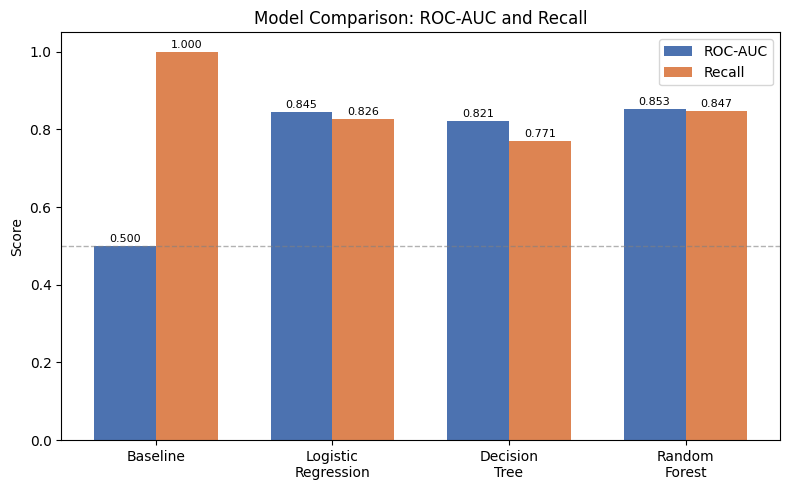

In [11]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Baseline', 'Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
roc_aucs = [baseline_roc_auc, logreg_roc_auc, tree_roc_auc, rf_roc_auc]
recalls = [baseline_recall, logreg_recall, tree_recall, rf_recall]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, roc_aucs, width, label='ROC-AUC', color='#4C72B0')
bars2 = ax.bar(x + width/2, recalls, width, label='Recall', color='#DD8452')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: ROC-AUC and Recall')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

fig.tight_layout()
fig.savefig('chart_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Error analysis

Confusion matrices for all three real models -- used here only to understand the pattern of mistakes

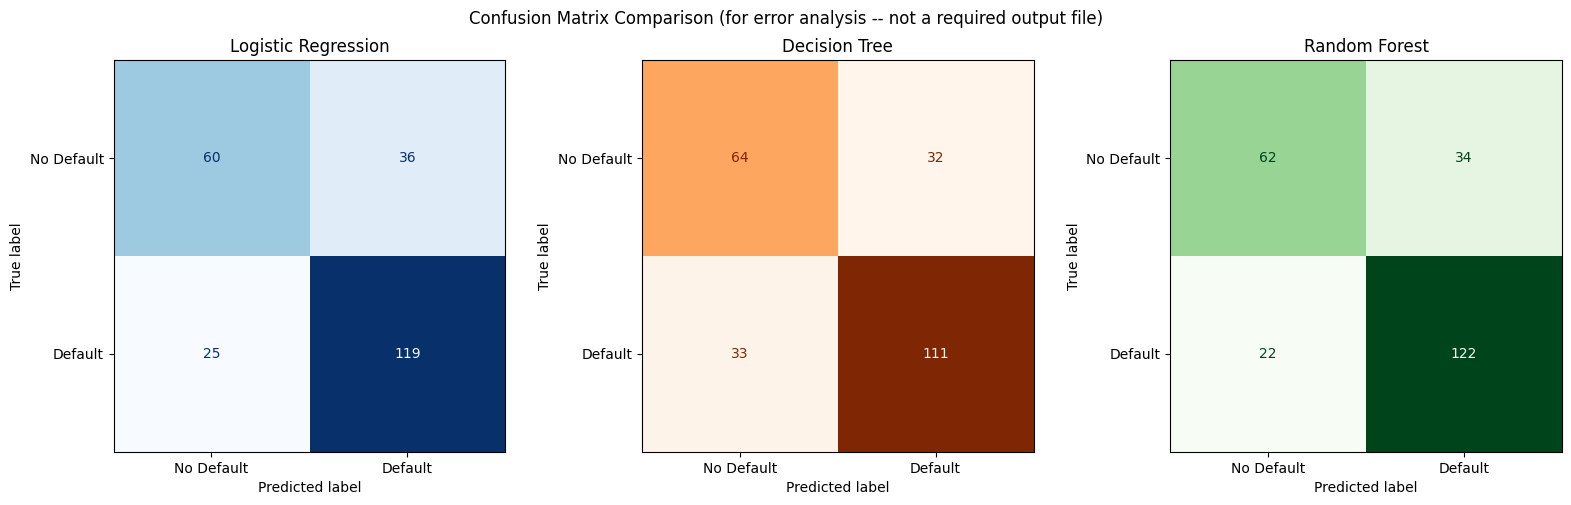

Logistic Regression:
 [[ 60  36]
 [ 25 119]]

Decision Tree:
 [[ 64  32]
 [ 33 111]]

Random Forest:
 [[ 62  34]
 [ 22 122]]


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_logreg = confusion_matrix(y_test, y_pred_logreg_scaled, labels=[0, 1])
cm_tree = confusion_matrix(y_test, y_pred_tree, labels=[0, 1])
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay(cm_logreg, display_labels=['No Default', 'Default']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(cm_tree, display_labels=['No Default', 'Default']).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Decision Tree')

ConfusionMatrixDisplay(cm_rf, display_labels=['No Default', 'Default']).plot(ax=axes[2], cmap='Greens', colorbar=False)
axes[2].set_title('Random Forest')

fig.suptitle('Confusion Matrix Comparison (for error analysis -- not a required output file)')
fig.tight_layout()
plt.show()

print("Logistic Regression:\n", cm_logreg)
print("\nDecision Tree:\n", cm_tree)
print("\nRandom Forest:\n", cm_rf)

### Error analysis findings

Random Forest not only leads on every aggregate metric, it also makes the fewest costly mistakes: only **22 false negatives** (actual defaulters predicted as safe) out of 144 actual defaulters, compared to 25 for Logistic Regression and 33 for Decision Tree. Unlike a case where the model with the best aggregate numbers turns out to hide a worse error pattern, here Random Forest's strength is consistent across both the summary metrics and the actual mistake breakdown -- it is genuinely the strongest model on this dataset, not just on paper.

Decision Tree is the weakest by both measures: lowest ROC-AUC (0.821) and the most costly false negatives (33), suggesting its single-tree structure (max_depth=5) captures less of the real signal than either the linear boundary of logistic regression or the ensemble averaging of random forest.

## Step 9: Calibration — final model (Random Forest)

Checking whether Random Forest's predicted probabilities are trustworthy -- i.e., when it says "80% chance of default," do roughly 80% of those applicants actually default?

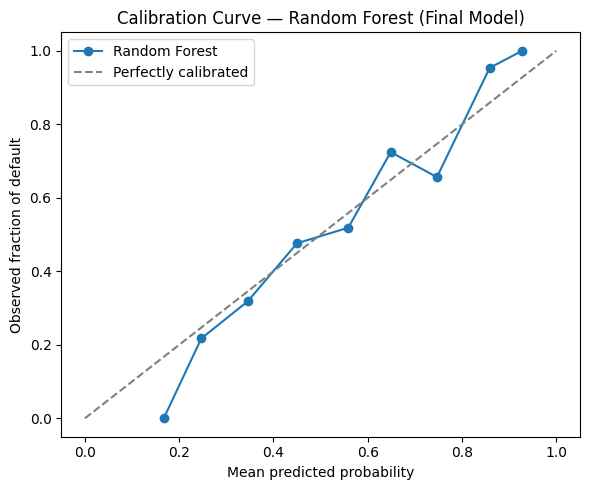

Brier Score — Random Forest: 0.155


In [13]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_proba_rf, n_bins=10)
brier_rf = brier_score_loss(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(prob_pred_rf, prob_true_rf, marker='o', label='Random Forest')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed fraction of default')
ax.set_title('Calibration Curve — Random Forest (Final Model)')
ax.legend()
fig.tight_layout()
fig.savefig('chart_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Brier Score — Random Forest: {brier_rf:.3f}")

   ### Calibration findings
   
   Random Forest's Brier score is **0.155**, indicating reasonably well-calibrated probabilities. The curve tracks the diagonal fairly closely, with some noise at the extremes likely due to small bin sizes (~24 points per bin on a 240-row test set).

## Step 10: Save required output — model_metrics.json

In [14]:
import json

model_metrics = {
    "baseline": {
        "accuracy": float(baseline_accuracy),
        "precision": float(baseline_precision),
        "recall": float(baseline_recall),
        "f1": float(baseline_f1),
        "roc_auc": float(baseline_roc_auc)
    },
    "logistic_regression": {
        "accuracy": float(logreg_accuracy),
        "precision": float(logreg_precision),
        "recall": float(logreg_recall),
        "f1": float(logreg_f1),
        "roc_auc": float(logreg_roc_auc)
    },
    "decision_tree": {
        "accuracy": float(tree_accuracy),
        "precision": float(tree_precision),
        "recall": float(tree_recall),
        "f1": float(tree_f1),
        "roc_auc": float(tree_roc_auc)
    },
    "random_forest": {
        "accuracy": float(rf_accuracy),
        "precision": float(rf_precision),
        "recall": float(rf_recall),
        "f1": float(rf_f1),
        "roc_auc": float(rf_roc_auc)
    },
    "credit_score_imputation_value": float(credit_score_fill_value),
    "final_model": "random_forest"
}

with open("model_metrics.json", "w") as f:
    json.dump(model_metrics, f, indent=2)

print(json.dumps(model_metrics, indent=2))

{
  "baseline": {
    "accuracy": 0.6,
    "precision": 0.6,
    "recall": 1.0,
    "f1": 0.75,
    "roc_auc": 0.5
  },
  "logistic_regression": {
    "accuracy": 0.7458333333333333,
    "precision": 0.7677419354838709,
    "recall": 0.8263888888888888,
    "f1": 0.7959866220735786,
    "roc_auc": 0.8454137731481481
  },
  "decision_tree": {
    "accuracy": 0.7291666666666666,
    "precision": 0.7762237762237763,
    "recall": 0.7708333333333334,
    "f1": 0.7735191637630662,
    "roc_auc": 0.8211443865740741
  },
  "random_forest": {
    "accuracy": 0.7666666666666667,
    "precision": 0.782051282051282,
    "recall": 0.8472222222222222,
    "f1": 0.8133333333333334,
    "roc_auc": 0.8529369212962962
  },
  "credit_score_imputation_value": 649.0,
  "final_model": "random_forest"
}


##  Hyperparameter tuning with GridSearchCV

Trying multiple combinations of Random Forest hyperparameters systematically, using cross-validation on the training set only, instead of manually guessing `max_depth=5` and `n_estimators=100`.

In [15]:
from sklearn.model_selection import GridSearchCV

# Different combinations to try
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',      # the metric on basis of which "best" will be decided
    cv=5,                   # 5-fold cross-validation
    n_jobs=-1                # use all cpu cores for fast processing
)

grid_search.fit(X_train, y_train)   

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation ROC-AUC: {grid_search.best_score_:.3f}")

Best parameters: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 50}
Best cross-validation ROC-AUC: 0.842


In [16]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"Tuned Random Forest ROC-AUC on test set: {roc_auc_score(y_test, y_proba_best_rf):.3f}")
print(f"Original Random Forest ROC-AUC on test set: {rf_roc_auc:.3f}")

Tuned Random Forest ROC-AUC on test set: 0.854
Original Random Forest ROC-AUC on test set: 0.853


## Feature importance

Checking which features Random Forest relied on most to predict default -- does it match the domain intuition (credit_score and loan-to-income ratio should matter most)?

                         Feature  Importance
0                   credit_score    0.678290
1               applicant_income    0.163399
2                    loan_amount    0.133263
3       employment_type_Salaried    0.014889
4  employment_type_Self-Employed    0.010160


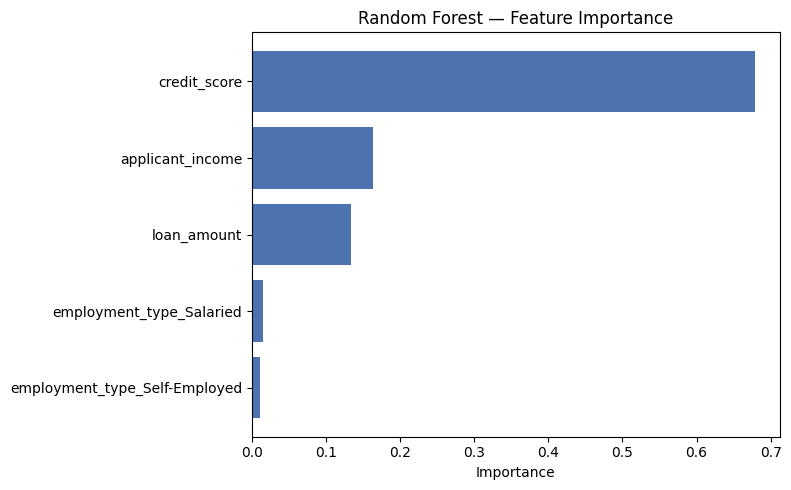

In [17]:
importances = rf_clf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(importance_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='#4C72B0')
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Feature Importance')
ax.invert_yaxis()  # sabse important upar dikhe
fig.tight_layout()
plt.show()

### Feature importance findings

`credit_score` dominates with **67.8%** importance, far ahead of `applicant_income` (16.3%) and `loan_amount` (13.3%). `employment_type`'s two dummy columns combined contribute only **2.5%**, making it the least useful feature by a wide margin.

This aligns with how the dataset was generated: credit_score's wide numeric range (300-850) gives it more overall influence on the underlying risk formula than employment type's three discrete risk levels, even though random forest had no knowledge of the generation formula -- it inferred this pattern purely from the data.

In [19]:
# employment_type ke bina model banao
X_train_reduced = X_train.drop(columns=['employment_type_Salaried', 'employment_type_Self-Employed'])
X_test_reduced = X_test.drop(columns=['employment_type_Salaried', 'employment_type_Self-Employed'])

rf_reduced = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_reduced.fit(X_train_reduced, y_train)
y_proba_reduced = rf_reduced.predict_proba(X_test_reduced)[:, 1]

print(f"Full model ROC-AUC:    {rf_roc_auc:.3f}")
print(f"Reduced model ROC-AUC: {roc_auc_score(y_test, y_proba_reduced):.3f}")

Full model ROC-AUC:    0.853
Reduced model ROC-AUC: 0.848


### Bonus: Feature importance and reduced model

Random Forest's feature importances showed `credit_score` dominating (67.8%), with `employment_type` contributing only ~2.5% combined. Dropping `employment_type` entirely resulted in only a marginal ROC-AUC drop (0.853 → 0.848), suggesting the feature could be excluded for a simpler model with minimal cost -- though the full model was still used as the shipped `final_model` since the small remaining gain was worth keeping given the high-stakes nature of lending decisions.

## Threshold tuning

The default 0.5 cutoff isn't special -- exploring how shifting it changes the precision/recall trade-off for Random Forest (the final model), since missing an actual defaulter (false negative) is the costliest mistake in this context.

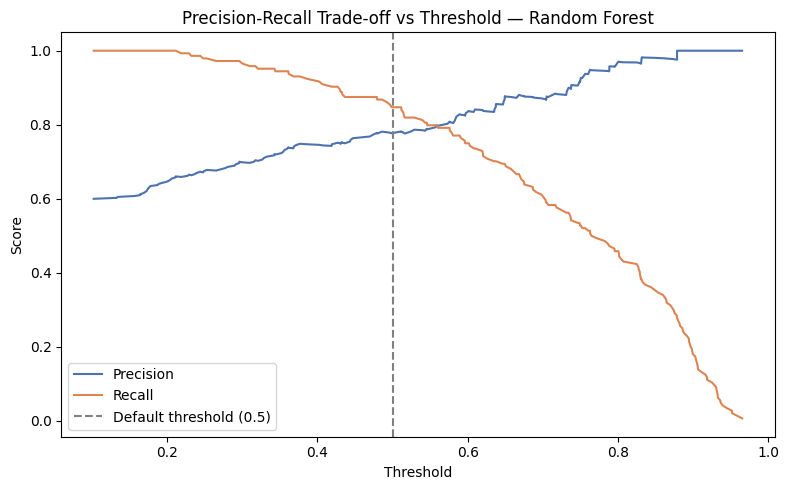

In [20]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#4C72B0')
ax.plot(thresholds, recalls[:-1], label='Recall', color='#DD8452')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall Trade-off vs Threshold — Random Forest')
ax.legend()
fig.tight_layout()
plt.show()

In [21]:
custom_threshold = 0.35

y_pred_custom = (y_proba_rf >= custom_threshold).astype(int)

print(f"At threshold = 0.5 (default):")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rf):.3f}")

print(f"\nAt threshold = {custom_threshold}:")
print(f"  Precision: {precision_score(y_test, y_pred_custom):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_custom):.3f}")

cm_custom = confusion_matrix(y_test, y_pred_custom, labels=[0, 1])
print(f"\nConfusion matrix at threshold {custom_threshold}:\n{cm_custom}")

At threshold = 0.5 (default):
  Precision: 0.782
  Recall:    0.847

At threshold = 0.35:
  Precision: 0.723
  Recall:    0.944

Confusion matrix at threshold 0.35:
[[ 44  52]
 [  8 136]]


### Threshold tuning findings

Lowering the classification threshold from 0.5 to 0.35 reduced false negatives from 22 to 8 -- catching 14 more actual defaulters -- at the cost of raising false positives from 34 to 52 (18 more genuinely-safe applicants incorrectly flagged). This confirms the threshold is a tunable business decision, not a fixed property of the model: for a lender where missing a defaulter is far costlier than rejecting a safe applicant, 0.35 would be the better operating point despite its lower precision (0.723 vs 0.782).

##  Gradient Boosting

Trying a fourth model type -- Gradient Boosting builds trees sequentially, with each new tree correcting the previous trees' errors, unlike Random Forest's independent/parallel trees.

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)
y_proba_gb = gb_clf.predict_proba(X_test)[:, 1]

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, y_proba_gb)

print(f"Gradient Boosting Accuracy:  {gb_accuracy:.3f}")
print(f"Gradient Boosting Precision: {gb_precision:.3f}")
print(f"Gradient Boosting Recall:    {gb_recall:.3f}")
print(f"Gradient Boosting F1:        {gb_f1:.3f}")
print(f"Gradient Boosting ROC-AUC:   {gb_roc_auc:.3f}")

print(f"\nFor comparison -- Random Forest ROC-AUC: {rf_roc_auc:.3f}")

Gradient Boosting Accuracy:  0.742
Gradient Boosting Precision: 0.766
Gradient Boosting Recall:    0.819
Gradient Boosting F1:        0.792
Gradient Boosting ROC-AUC:   0.846

For comparison -- Random Forest ROC-AUC: 0.853


### Gradient Boosting findings

Gradient Boosting (ROC-AUC 0.846) did not outperform the tuned Random Forest (0.853) on this dataset, despite boosting often being considered a stronger default choice for tabular data. This is likely because Gradient Boosting was run with default/untuned hyperparameters (unlike Random Forest, which went through GridSearchCV), and because the underlying pattern in this dataset is relatively simple -- feature importance showed credit_score alone accounting for 67.8% of the signal, leaving less room for boosting's sequential error-correction to add value over Random Forest's averaging approach. **Random Forest remains the strongest model overall** and stays the `final_model` choice.